In [52]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel(r"D:\Projects\Data\Sleep_Work_Productivity_Surve.xlsx")

# clean age column
df['Enter your age ?']= df['Enter your age ?'].fillna(df['Enter your age ?'].median())

# rename the columns
df.rename(columns={
    'How would you rate your overall work productivity?': 'work_productivity',
    'How much do you think your sleep affects your productivity at work?': 'sleep_productivity_effect',
    'What factors do you believe impact your sleep quality? (Select all that apply)': 'sleep_factors',
    'How many breaks do you take during your workday when you are tired ?': 'break_nums',
    'How would you describe your energy levels throughout the workday?': 'energy_levels_per_workday',
    'What is your primary work environment?': 'primary_work_environment',
    'what is you gender ?': 'gender',
    'On a typical work night, how many hours of sleep do you get?': 'sleep_hours',
    
    'I wake up feeling refreshed and ready for work.':
        'wake_up_refreshed',

    'I have difficulty falling asleep the night before an important workday.':
        'difficulty_falling_asleep',

    'Enter your age ?':
        'age',

    'I wake up multiple times during the night and struggle to go back to sleep.':
        'wake_up_multiple_times',

    'On weekends or days off, my sleep schedule is very different from my workday schedule (e.g., sleeping in more than 2 hours later).':
        'weekend_sleep_schedule_difference',

    'I use electronic devices (phone, laptop, TV) in bed within 30 minutes of trying to sleep.':
        'device_use_before_sleep',

    'I find it hard to concentrate on work tasks for more than 15–20 minutes at a time.':
        'difficulty_concentrating',

    'I make careless mistakes (e.g., typos, miscalculations, forgetting steps) that I would not have made if better rested.':
        'careless_mistakes',

    'I often have to re-read emails, documents, or instructions because I lost focus.':
        'reread_due_to_focus_loss',

    'Learning a new software, process, or skill at work feels unusually difficult for me.':
        'difficulty_learning_new_skills',

    'I struggle to generate new ideas or creative solutions to problems.':
        'difficulty_generating_ideas',

    'I forget important tasks, deadlines, or details from meetings.':
        'forget_tasks_deadlines',

    'I feel irritable or short-tempered with colleagues or clients.':
        'irritable_with_colleagues',

    'Small setbacks or minor criticism feel overwhelming or upsetting.':
        'small_setbacks_overwhelming',

    'I avoid collaboration or group work because I feel mentally exhausted.':
        'avoid_collaboration',

    'I have difficulty controlling my emotions during stressful work situations (e.g., tight deadlines, difficult customers).':
        'difficulty_controlling_emotions',

    'I feel physically tired, sluggish, or heavy-eyed during work, even without heavy physical exertion.':
        'physically_tired_at_work',

    'In my job, I have had a close call, minor accident, or injury that I attribute to being too tired. If your job is sedentary, answer based on accidents like tripping, bumping into things, or spilling hot liquids.':
        'accident_due_to_tiredness',

    'Compared to when I am well-rested, I estimate my current work output is...':
        'current_work_output',

    'In the past month, how many work days did you feel you were “present but not productive” (getting less than half of your normal output) due to poor sleep?':
        'unproductive_workdays_due_to_sleep'

}, inplace=True)


# clean the names
df = df.replace(r'\n', ', ', regex=True)
df["sleep_factors"] = df["sleep_factors"].str.split(", ")


# Reverse the only positive-direction question
df['wake_up_refreshed_reverse'] = 6 - df['wake_up_refreshed']


# clean unproductive_workdays_due_to_sleep outlires
df.loc[df["unproductive_workdays_due_to_sleep"] > 23,
       "unproductive_workdays_due_to_sleep"] = np.nan

median = df['unproductive_workdays_due_to_sleep'].median().round(0)
df['unproductive_workdays_due_to_sleep'] = df['unproductive_workdays_due_to_sleep'].fillna(median)


# 1. Sleep Quality and Hygiene Index (SQLI)
# 5 questions × maximum score of 5 = 25
# Divide by 25 and multiply by 100 → maximum possible score = 100
df['sleep_quality_and_hygiene_index_(SQLI)'] = (
    (
        df['wake_up_refreshed_reverse']
        + df['difficulty_falling_asleep']
        + df['wake_up_multiple_times']
        + df['weekend_sleep_schedule_difference']
        + df['device_use_before_sleep']
    ) / 25
) * 100


# 2. Cognitive at-task Performance Index (CTPI)
# 6 questions × maximum score of 5 = 30
# Divide by 30 and multiply by 100 → maximum possible score = 100
df['Cognitive_at_task_perforamnce_index_(CTPI)'] = (
    (df['difficulty_concentrating']
     + df['careless_mistakes']
     + df['reread_due_to_focus_loss']
     + df['difficulty_learning_new_skills']
     + df['difficulty_generating_ideas']
     + df['forget_tasks_deadlines']) / 30
) * 100

df['Cognitive_at_task_perforamnce_index_(CTPI)'] = (
    df['Cognitive_at_task_perforamnce_index_(CTPI)'].round(2)
)


# 3. Emotional and Social Impact Index (ESII)
# 4 questions × maximum score of 5 = 20
# Divide by 20 and multiply by 100 → maximum possible score = 100
df['Emotional_and_social_impact_index(ESII)'] = (
    (df['irritable_with_colleagues']
     + df['small_setbacks_overwhelming']
     + df['avoid_collaboration']
     + df['difficulty_controlling_emotions']) / 20
) * 100


# 4. Physical and Safety Risk Index (PSRI)
# 2 questions × maximum score of 5 = 10
# Divide by 10 and multiply by 100 → maximum possible score = 100
df['Physical_and_safety_risk_index(PSRI)'] = (
    (df['physically_tired_at_work']
     + df['accident_due_to_tiredness']) / 10
) * 100


# 5. Presentative Index (PI)
output_loss_map = {
    'About the same or better': 0.00,
    '20–40% less': 0.30,
    '40–60% less': 0.50,
    '60–80% less': 0.70,
    '80–100% less':1.00
}

df['productivity_loss_fraction'] = (
    df['current_work_output'].map(output_loss_map)
)

df['Presentative_index(PI)'] = (
    (df['unproductive_workdays_due_to_sleep'] / 23)
    * df['productivity_loss_fraction']
    * 100
)

df['Presentative_index(PI)'] = (
    df['Presentative_index(PI)'].round(2)
)


# 6. Overall Sleep Productivity Impact Index (SPI)
# Each component has a maximum of 100.
# Therefore, their total maximum = 400.
# Dividing by 4 gives an average with a maximum of 100.
df['Overall_sleep_Productivity_Impact_index(SPI)'] = (
    df['Cognitive_at_task_perforamnce_index_(CTPI)']
    + df['Emotional_and_social_impact_index(ESII)']
    + df['Physical_and_safety_risk_index(PSRI)']
    + df['Presentative_index(PI)']
) / 4

## **The Qs We Are Going To Answer, Using ML Models**

### ML 1 — SPI
- Can we predict overall sleep-related productivity impact (categorized) from workers' sleep, work, and demographic characteristics, and which - - - characteristics are the most important predictors?

#### --> first of all we should split our data into 3 parts:
#### 1) df1 (the df what we wanna encode)
#### 2) df2 (the df what we will extract variables from)
#### 3) df3 (our lables)

In [53]:
df1 = df.loc[:, 'Submission Date':'sleep_hours']
df1['current_work_output']= df['current_work_output']
df1 = df1.drop(columns='sleep_factors')

In [54]:
df2 = df.loc[:,'wake_up_refreshed':].drop(columns=['Overall_sleep_Productivity_Impact_index(SPI)', 'sleep_quality_and_hygiene_index_(SQLI)', 'current_work_output'])

In [55]:
df3 = df[['Overall_sleep_Productivity_Impact_index(SPI)', 'sleep_quality_and_hygiene_index_(SQLI)']]

In [56]:
#encode the variables of df1
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

encoded = encoder.fit_transform(
    df1[['primary_work_environment', 'gender']]
)

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(
        ['primary_work_environment', 'gender']
    ),
    index=df1.index
)

df1 = pd.concat([df1, encoded_df], axis=1)


work_productivity_map = {
    'Low': 0,
    'Moderate': 1,
    'High': 2,
    'Very high': 3
}

df1['work_productivity_encoded'] = (
    df1['work_productivity'].map(work_productivity_map)
)


sleep_effect_map = {
    'Not at all': 0,
    'A little': 1,
    'Moderately': 2,
    'Significantly': 3,
    'Extremely': 4
}

df1['sleep_productivity_effect_encoded'] = (
    df1['sleep_productivity_effect'].map(sleep_effect_map)
)


break_map = {
    '1-2': 1,
    '3-4': 2,
    '5 or more': 3
}

df1['break_nums_encoded'] = (
    df1['break_nums'].map(break_map)
)

break_nums_encoded_median = df1['break_nums_encoded'].median()
df1['break_nums_encoded'] = df1['break_nums_encoded'].fillna(break_nums_encoded_median)


energy_map = {
    'Very low': 0,
    'Low': 1,
    'Moderate': 2,
    'High': 3,
    'Very high': 4
}

df1['energy_encoded'] = (
    df1['energy_levels_per_workday'].map(energy_map)
)


sleep_hours_map = {
    'Less than 5 hrs': 0,
    '5–6 hrs': 1,
    '6–7 hrs': 2,
    '7–8 hrs': 3,
    'More than 8 hrs': 4
}

df1['sleep_hours_encoded'] = (
    df1['sleep_hours'].map(sleep_hours_map)
)


output_loss_map = {
    'About the same or better': 0.00,
    '20–40% less': 0.30,
    '40–60% less': 0.50,
    '60–80% less': 0.70,
    '80–100% less': 1.00
}




In [57]:
df1_encoded = df1.iloc[:, 9:]
df3_SPI = df3['Overall_sleep_Productivity_Impact_index(SPI)']

In [58]:
df_SPI = pd.concat([df1_encoded, df2, df3_SPI], axis=1)

In [59]:
X1 = df_SPI.drop(columns=[
    'Overall_sleep_Productivity_Impact_index(SPI)',
    'Cognitive_at_task_perforamnce_index_(CTPI)',
    'Emotional_and_social_impact_index(ESII)',
    'Physical_and_safety_risk_index(PSRI)',
    'Presentative_index(PI)',
    'wake_up_refreshed'
])

y1 = df_SPI['Overall_sleep_Productivity_Impact_index(SPI)']

In [60]:
y1_class = pd.qcut(
    y1,
    q=3,
    labels=["Low", "Medium", "High"]
)

y1 = y1_class

In [61]:
from sklearn.model_selection import train_test_split

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.2,
    random_state=42,
    stratify=y1
)

In [62]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [63]:
# Model 1 — Logistic Regression
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])


# Model 2 — Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)


# Model 3 — Gradient Boosting
gb_model = GradientBoostingClassifier(
    random_state=42
)

In [64]:
# Train Logistic Regression
logistic_model = logistic_model.fit(X1_train, y1_train)

# Train Random Forest
rf_model = rf_model.fit(X1_train, y1_train)

# Train Gradient Boosting
gb_model = gb_model.fit(X1_train, y1_train)

In [65]:
y1_pred_logistic = logistic_model.predict(X1_test)

y1_pred_rf = rf_model.predict(X1_test)

y1_pred_gb = gb_model.predict(X1_test)

In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [67]:
print("Logistic Regression")

print("Accuracy:",
      accuracy_score(y1_test, y1_pred_logistic))

print("Precision:",
      precision_score(
          y1_test,
          y1_pred_logistic,
          average="weighted"
      ))

print("Recall:",
      recall_score(
          y1_test,
          y1_pred_logistic,
          average="weighted"
      ))

print("F1-score:",
      f1_score(
          y1_test,
          y1_pred_logistic,
          average="weighted"
      ))

print("\nConfusion Matrix:")
print(confusion_matrix(y1_test, y1_pred_logistic))

Logistic Regression
Accuracy: 0.8076923076923077
Precision: 0.8386613386613386
Recall: 0.8076923076923077
F1-score: 0.8121278875922838

Confusion Matrix:
[[6 0 3]
 [0 8 1]
 [1 0 7]]


In [68]:
print("Random Forest")

print("Accuracy:",
      accuracy_score(y1_test, y1_pred_rf))

print("Precision:",
      precision_score(
          y1_test,
          y1_pred_rf,
          average="weighted"
      ))

print("Recall:",
      recall_score(
          y1_test,
          y1_pred_rf,
          average="weighted"
      ))

print("F1-score:",
      f1_score(
          y1_test,
          y1_pred_rf,
          average="weighted"
      ))

print("\nConfusion Matrix:")
print(confusion_matrix(y1_test, y1_pred_rf))

Random Forest
Accuracy: 0.8846153846153846
Precision: 0.8836538461538462
Recall: 0.8846153846153846
F1-score: 0.8822338652060014

Confusion Matrix:
[[7 1 1]
 [0 9 0]
 [1 0 7]]


In [69]:
print("Gradient Boosting")

print("Accuracy:",
      accuracy_score(y1_test, y1_pred_gb))

print("Precision:",
      precision_score(
          y1_test,
          y1_pred_gb,
          average="weighted"
      ))

print("Recall:",
      recall_score(
          y1_test,
          y1_pred_gb,
          average="weighted"
      ))

print("F1-score:",
      f1_score(
          y1_test,
          y1_pred_gb,
          average="weighted"
      ))

print("\nConfusion Matrix:")
print(confusion_matrix(y1_test, y1_pred_gb))

Gradient Boosting
Accuracy: 0.8076923076923077
Precision: 0.8422090729783037
Recall: 0.8076923076923077
F1-score: 0.8058816183816184

Confusion Matrix:
[[7 1 1]
 [0 9 0]
 [0 3 5]]


In [70]:
results_spi = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y1_test, y1_pred_logistic),
        accuracy_score(y1_test, y1_pred_rf),
        accuracy_score(y1_test, y1_pred_gb)
    ],
    "Precision": [
        precision_score(y1_test, y1_pred_logistic, average="weighted"),
        precision_score(y1_test, y1_pred_rf, average="weighted"),
        precision_score(y1_test, y1_pred_gb, average="weighted")
    ],
    "Recall": [
        recall_score(y1_test, y1_pred_logistic, average="weighted"),
        recall_score(y1_test, y1_pred_rf, average="weighted"),
        recall_score(y1_test, y1_pred_gb, average="weighted")
    ],
    "F1-score": [
        f1_score(y1_test, y1_pred_logistic, average="weighted"),
        f1_score(y1_test, y1_pred_rf, average="weighted"),
        f1_score(y1_test, y1_pred_gb, average="weighted")
    ]
})

results_spi

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.807692,0.838661,0.807692,0.812128
1,Random Forest,0.884615,0.883654,0.884615,0.882234
2,Gradient Boosting,0.807692,0.842209,0.807692,0.805882


In [71]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

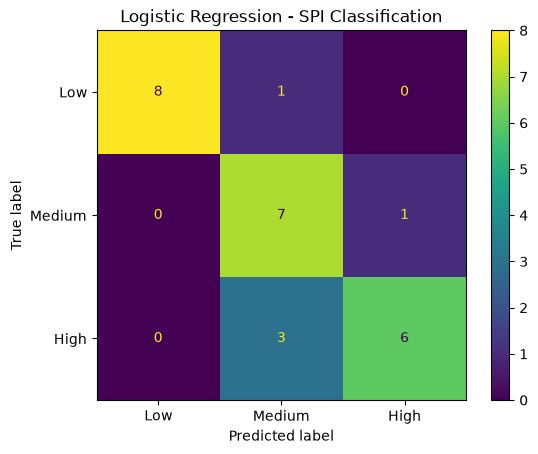

In [72]:
ConfusionMatrixDisplay.from_predictions(
    y1_test,
    y1_pred_logistic,
    labels=["Low", "Medium", "High"]
)

plt.title("Logistic Regression - SPI Classification")
plt.show()

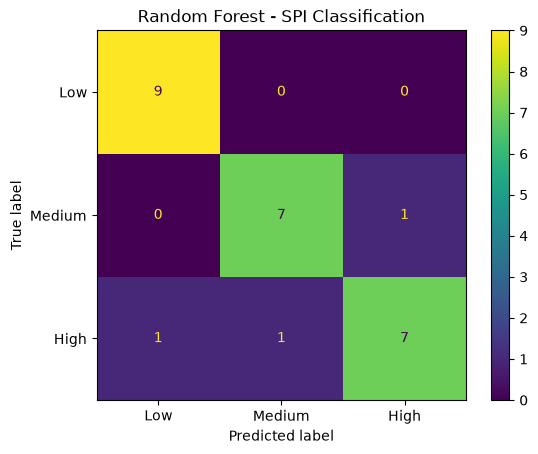

In [73]:
ConfusionMatrixDisplay.from_predictions(
    y1_test,
    y1_pred_rf,
    labels=["Low", "Medium", "High"]
)

plt.title("Random Forest - SPI Classification")
plt.show()

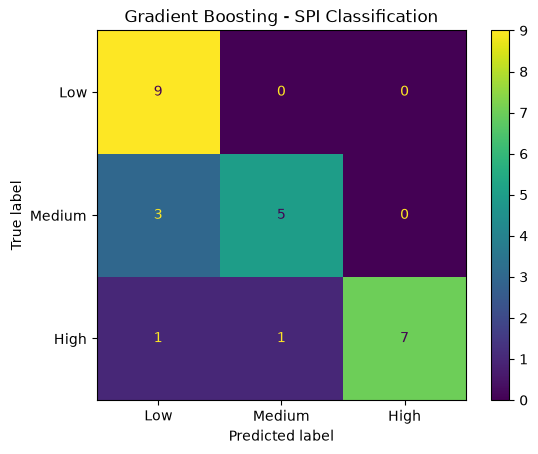

In [74]:
ConfusionMatrixDisplay.from_predictions(
    y1_test,
    y1_pred_gb,
    labels=["Low", "Medium", "High"]
)

plt.title("Gradient Boosting - SPI Classification")
plt.show()